# ✦ NHANES Caffeine Input Analysis

## Finding the Minimum, Maximum, and Descriptive Statistics for Caffeine Intake

This notebook analyzes the caffeine input variable for the sleep installation.

The installation may represent this through a coffee or drink station, but the dataset variable is broader than coffee.

The main variable is:

**caffeine_mg**

This comes from NHANES:

**DR1TCAFF**

It measures total caffeine intake in milligrams from the first 24-hour dietary recall.

The goal is to find:

| Statistic   | Meaning                 |
| ----------- | ----------------------- |
| Minimum     | Lowest caffeine intake  |
| Maximum     | Highest caffeine intake |
| Mean        | Average caffeine intake |
| Median      | Middle caffeine intake  |
| Percentiles | Main distribution range |
| Outliers    | Extremely high values   |

This helps us decide what caffeine input range the installation should use.


In [1]:
from pathlib import Path
import requests
import pandas as pd
from tqdm.auto import tqdm

# Find the main project folder.
# This is useful because this notebook is inside the Notebooks folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

# Create organized folders
DATA_DIR = PROJECT_DIR / "data" / "nhanes"
GRAPH_DIR = PROJECT_DIR / "Graphs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Current folder:", CURRENT_DIR)
print("Project folder:", PROJECT_DIR)
print("NHANES data folder:", DATA_DIR)
print("Graph folder:", GRAPH_DIR)

Current folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Notebooks
Project folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis
NHANES data folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\nhanes
Graph folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs


---

# 2. ✧ Loading the NHANES Dietary Totals Dataset

For the caffeine input, we use the NHANES dietary totals dataset.

The variable we need is:

**DR1TCAFF**

This measures total caffeine intake in milligrams from the first 24-hour dietary recall.

In the installation, this variable will be represented as:

**caffeine_mg**

Even though the interaction may look like a coffee or drink station, the dataset variable includes total caffeine intake, not only coffee.


In [2]:
# NHANES 2017–March 2020 Dietary Interview: Total Nutrient Intakes, First Day
DR1TOT_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DR1TOT.XPT"

DR1TOT_FILE = DATA_DIR / "P_DR1TOT.XPT"

def download_file(url, destination):
    if destination.exists():
        print("File already exists, skipping download:")
        print(destination)
        return

    print("Downloading file...")
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(destination, "wb") as file, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))

    print("Download finished!")

download_file(DR1TOT_URL, DR1TOT_FILE)

# Load the NHANES XPT file
caffeine_df = pd.read_sas(DR1TOT_FILE, format="xport")

print("Rows:", len(caffeine_df))
print("Columns:", len(caffeine_df.columns))

caffeine_df.head()

Downloading: 0.00B [00:00, ?B/s]

Download finished!
Rows: 14300
Columns: 168


,SEQN,WTDRD1PP,WTDR2DPP,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,...,DRD370QQ,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V
0,109263.0,7619.483586,17808.067666,1.0,14.0,2.0,2.0,4.0,6.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264.0,8235.895818,7253.761719,1.0,81.0,2.0,2.0,5.0,6.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109265.0,33535.080310,35612.007356,1.0,88.0,2.0,2.0,19.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109266.0,6831.068440,5988.203624,1.0,81.0,2.0,2.0,4.0,7.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109269.0,7875.706968,18231.925894,1.0,88.0,2.0,2.0,9.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

# 3. ✧ Selecting and Describing the Caffeine Variable

Now we select the caffeine variable from the NHANES dietary totals dataset.

The original NHANES variable is:

**DR1TCAFF**

In this notebook, we rename it to:

**caffeine_mg**

This variable represents total caffeine intake in milligrams from the first 24-hour dietary recall.

The goal of this step is to calculate the first descriptive statistics:

| Statistic          | Meaning                      |
| ------------------ | ---------------------------- |
| Count              | Number of valid participants |
| Minimum            | Lowest caffeine intake       |
| Median             | Middle caffeine intake       |
| Mean               | Average caffeine intake      |
| Maximum            | Highest caffeine intake      |
| Standard deviation | Spread between participants  |


In [3]:
# ------------------------------------------------------------
# Select and prepare caffeine variable
# ------------------------------------------------------------

caffeine_analysis = caffeine_df[
    [
        "SEQN",
        "DR1TCAFF"
    ]
].copy()

# Rename variable for the project
caffeine_analysis = caffeine_analysis.rename(
    columns={
        "DR1TCAFF": "caffeine_mg"
    }
)

# Make sure caffeine is numeric
caffeine_analysis["caffeine_mg"] = pd.to_numeric(
    caffeine_analysis["caffeine_mg"],
    errors="coerce"
)

# Keep only valid non-negative caffeine values
caffeine_analysis = caffeine_analysis[
    caffeine_analysis["caffeine_mg"].notna() &
    (caffeine_analysis["caffeine_mg"] >= 0)
].copy()

caffeine = caffeine_analysis["caffeine_mg"]

print("Caffeine input descriptive statistics")
print("-------------------------------------")
print("Valid participants:", len(caffeine_analysis))
print("Minimum:", round(caffeine.min(), 2), "mg/day")
print("Maximum:", round(caffeine.max(), 2), "mg/day")
print("Mean:", round(caffeine.mean(), 2), "mg/day")
print("Median:", round(caffeine.median(), 2), "mg/day")
print("Standard deviation:", round(caffeine.std(), 2), "mg/day")

print("\nFull descriptive statistics:")
print(caffeine.describe().to_string())

# Create a clean table for display
caffeine_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(caffeine.count())} participants",
        f"{caffeine.min():.2f} mg/day",
        f"{caffeine.quantile(0.25):.2f} mg/day",
        f"{caffeine.median():.2f} mg/day",
        f"{caffeine.mean():.2f} mg/day",
        f"{caffeine.quantile(0.75):.2f} mg/day",
        f"{caffeine.max():.2f} mg/day",
        f"{caffeine.std():.2f} mg/day"
    ],
    "Simple meaning": [
        "Number of valid participants analyzed",
        "Lowest daily caffeine intake",
        "25% of participants were at or below this value",
        "Middle daily caffeine intake",
        "Average daily caffeine intake",
        "75% of participants were at or below this value",
        "Highest daily caffeine intake",
        "How spread out the caffeine values are"
    ]
})

display(caffeine_stats_table)

Caffeine input descriptive statistics
-------------------------------------
Valid participants: 12392
Minimum: 0.0 mg/day
Maximum: 4320.0 mg/day
Mean: 95.57 mg/day
Median: 31.0 mg/day
Standard deviation: 174.82 mg/day

Full descriptive statistics:
count    1.239200e+04
mean     9.556617e+01
std      1.748170e+02
min      5.397605e-79
25%      5.397605e-79
50%      3.100000e+01
75%      1.370000e+02
max      4.320000e+03


,Statistic,Value,Simple meaning
0,Count,12392 participants,Number of valid participants analyzed
1,Minimum,0.00 mg/day,Lowest daily caffeine intake
2,25th percentile,0.00 mg/day,25% of participants were at or below this value
3,Median,31.00 mg/day,Middle daily caffeine intake
4,Mean,95.57 mg/day,Average daily caffeine intake
5,75th percentile,137.00 mg/day,75% of participants were at or below this value
6,Maximum,4320.00 mg/day,Highest daily caffeine intake
7,Standard deviation,174.82 mg/day,How spread out the caffeine values are


---

# 4. ✧ Checking Caffeine Outliers

The first descriptive table showed the full range of caffeine intake in the NHANES dataset.

Before choosing an installation range, we check whether any caffeine values are statistical outliers.

We use the IQR method:

**IQR = Q3 - Q1**

Then we calculate:

**Lower boundary = Q1 - 1.5 × IQR**

**Upper boundary = Q3 + 1.5 × IQR**

Values outside these boundaries are considered possible statistical outliers.

This step helps us avoid letting extreme caffeine values dominate the installation scale.


In [4]:
# ------------------------------------------------------------
# IQR outlier check for caffeine_mg
# ------------------------------------------------------------

caffeine = caffeine_analysis["caffeine_mg"].dropna()

# Calculate quartiles and IQR
caffeine_q1 = caffeine.quantile(0.25)
caffeine_q3 = caffeine.quantile(0.75)
caffeine_iqr = caffeine_q3 - caffeine_q1

# Calculate outlier boundaries
caffeine_lower_boundary = caffeine_q1 - 1.5 * caffeine_iqr
caffeine_upper_boundary = caffeine_q3 + 1.5 * caffeine_iqr

print("Caffeine IQR outlier check")
print("--------------------------")
print("Q1:", round(caffeine_q1, 2), "mg/day")
print("Q3:", round(caffeine_q3, 2), "mg/day")
print("IQR:", round(caffeine_iqr, 2), "mg/day")
print("Lower outlier boundary:", round(caffeine_lower_boundary, 2), "mg/day")
print("Upper outlier boundary:", round(caffeine_upper_boundary, 2), "mg/day")

# Identify outliers
caffeine_outlier_mask = (
    (caffeine_analysis["caffeine_mg"] < caffeine_lower_boundary) |
    (caffeine_analysis["caffeine_mg"] > caffeine_upper_boundary)
)

caffeine_outliers = caffeine_analysis[caffeine_outlier_mask].copy()
caffeine_analysis_clean = caffeine_analysis[~caffeine_outlier_mask].copy()

removed_percentage = (len(caffeine_outliers) / len(caffeine_analysis)) * 100

print("\nOutlier cleaning summary")
print("------------------------")
print("Original participants:", len(caffeine_analysis))
print("Detected outlier participants:", len(caffeine_outliers))
print("Cleaned participants:", len(caffeine_analysis_clean))
print("Removed percentage:", round(removed_percentage, 2), "%")

print("\nCleaned caffeine descriptive statistics:")
display(caffeine_analysis_clean["caffeine_mg"].describe())

print("\nHighest detected outlier values:")
display(
    caffeine_outliers
    .sort_values("caffeine_mg", ascending=False)
    .head(20)
)

Caffeine IQR outlier check
--------------------------
Q1: 0.0 mg/day
Q3: 137.0 mg/day
IQR: 137.0 mg/day
Lower outlier boundary: -205.5 mg/day
Upper outlier boundary: 342.5 mg/day

Outlier cleaning summary
------------------------
Original participants: 12392
Detected outlier participants: 708
Cleaned participants: 11684
Removed percentage: 5.71 %

Cleaned caffeine descriptive statistics:


count    1.168400e+04
mean     6.631761e+01
std      8.659791e+01
min      5.397605e-79
25%      5.397605e-79
50%      2.200000e+01
75%      1.100000e+02
max      3.420000e+02
Name: caffeine_mg, dtype: float64


Highest detected outlier values:


,SEQN,caffeine_mg
5371,115127.0,4320.0
6155,116005.0,3720.0
7982,118000.0,3600.0
12139,122499.0,3461.0
8991,119099.0,3456.0
906,110252.0,3216.0
2065,111510.0,2929.0
6,109271.0,2913.0
1035,110394.0,2405.0
7116,117044.0,2289.0


---

# 5. ✧ Describing Caffeine After Outlier Cleaning

The IQR method detected statistically extreme caffeine values.

Values above the upper outlier boundary of:

**342.50 mg/day**

were marked as outliers.

After removing these outliers, we create a cleaned descriptive statistics table for:

**caffeine_mg**

This cleaned version is more useful for the installation because it shows the main caffeine intake range without extreme values dominating the scale.


In [5]:
# ------------------------------------------------------------
# Descriptive statistics after caffeine outlier cleaning
# ------------------------------------------------------------

caffeine_cleaned = caffeine_analysis_clean["caffeine_mg"].dropna()

print("Cleaned caffeine input descriptive statistics")
print("---------------------------------------------")
print("Valid participants after cleaning:", len(caffeine_analysis_clean))
print("Minimum:", round(caffeine_cleaned.min(), 2), "mg/day")
print("Maximum:", round(caffeine_cleaned.max(), 2), "mg/day")
print("Mean:", round(caffeine_cleaned.mean(), 2), "mg/day")
print("Median:", round(caffeine_cleaned.median(), 2), "mg/day")
print("Standard deviation:", round(caffeine_cleaned.std(), 2), "mg/day")

print("\nFull cleaned descriptive statistics:")
print(caffeine_cleaned.describe().to_string())

# Create a clean table for display
caffeine_cleaned_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(caffeine_cleaned.count())} participants",
        f"{caffeine_cleaned.min():.2f} mg/day",
        f"{caffeine_cleaned.quantile(0.25):.2f} mg/day",
        f"{caffeine_cleaned.median():.2f} mg/day",
        f"{caffeine_cleaned.mean():.2f} mg/day",
        f"{caffeine_cleaned.quantile(0.75):.2f} mg/day",
        f"{caffeine_cleaned.max():.2f} mg/day",
        f"{caffeine_cleaned.std():.2f} mg/day"
    ],
    "Simple meaning": [
        "Number of valid participants after outlier cleaning",
        "Lowest daily caffeine intake",
        "25% of participants were at or below this value",
        "Middle daily caffeine intake",
        "Average daily caffeine intake",
        "75% of participants were at or below this value",
        "Highest daily caffeine intake after cleaning",
        "How spread out the cleaned caffeine values are"
    ]
})

display(caffeine_cleaned_stats_table)

Cleaned caffeine input descriptive statistics
---------------------------------------------
Valid participants after cleaning: 11684
Minimum: 0.0 mg/day
Maximum: 342.0 mg/day
Mean: 66.32 mg/day
Median: 22.0 mg/day
Standard deviation: 86.6 mg/day

Full cleaned descriptive statistics:
count    1.168400e+04
mean     6.631761e+01
std      8.659791e+01
min      5.397605e-79
25%      5.397605e-79
50%      2.200000e+01
75%      1.100000e+02
max      3.420000e+02


,Statistic,Value,Simple meaning
0,Count,11684 participants,Number of valid participants after outlier cle...
1,Minimum,0.00 mg/day,Lowest daily caffeine intake
2,25th percentile,0.00 mg/day,25% of participants were at or below this value
3,Median,22.00 mg/day,Middle daily caffeine intake
4,Mean,66.32 mg/day,Average daily caffeine intake
5,75th percentile,110.00 mg/day,75% of participants were at or below this value
6,Maximum,342.00 mg/day,Highest daily caffeine intake after cleaning
7,Standard deviation,86.60 mg/day,How spread out the cleaned caffeine values are


---

# 6. ✧ Graphing the Cleaned Caffeine Distribution

Now we create a distribution graph for the cleaned caffeine input variable.

This graph shows the spread of:

**caffeine_mg**

after removing statistical outliers.

The graph includes participants with 0 mg/day caffeine intake, because 0 caffeine is a real possible value in the dataset.


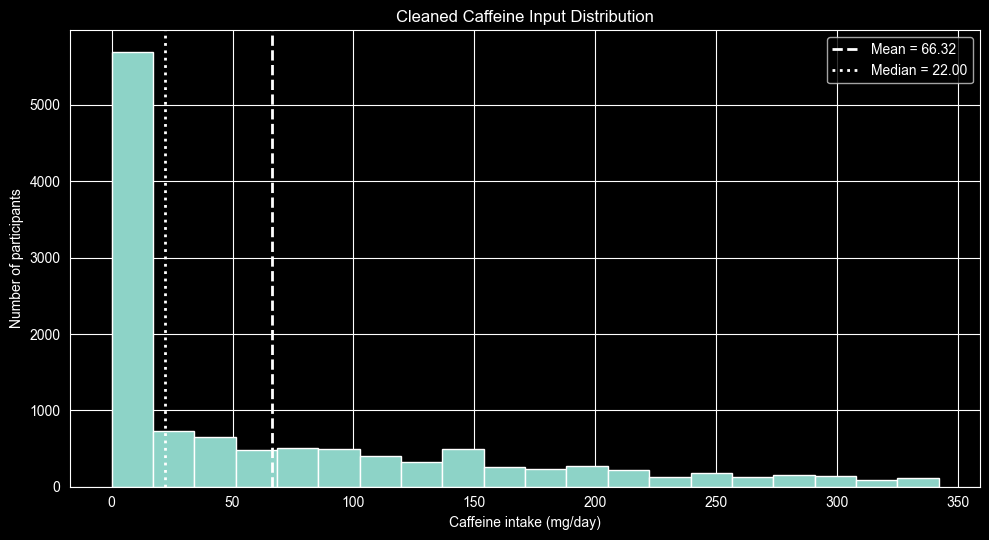

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\cleaned_caffeine_distribution.png


In [6]:
import matplotlib.pyplot as plt

# Select cleaned caffeine values
caffeine_cleaned = caffeine_analysis_clean["caffeine_mg"].dropna()

# Create the graph
plt.figure(figsize=(10, 5.5))

plt.hist(caffeine_cleaned, bins=20)

plt.axvline(
    caffeine_cleaned.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {caffeine_cleaned.mean():.2f}"
)

plt.axvline(
    caffeine_cleaned.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {caffeine_cleaned.median():.2f}"
)

plt.title("Cleaned Caffeine Input Distribution")
plt.xlabel("Caffeine intake (mg/day)")
plt.ylabel("Number of participants")
plt.legend()
plt.tight_layout()

# Save the graph
caffeine_graph_path = GRAPH_DIR / "cleaned_caffeine_distribution.png"
plt.savefig(caffeine_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(caffeine_graph_path)